In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import textwrap

# Company Overview: Apple Inc

In [8]:
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)
info = ticker.info

print("=" * 50)
print(f"Ticker        : {ticker_symbol}")
print(f"Company Name  : {info.get('longName', 'N/A')}")
print(f"Sector        : {info.get('sector', 'N/A')}")
print(f"Industry      : {info.get('industry', 'N/A')}")

# Market Cap
market_cap = info.get("marketCap", 0)
if market_cap >= 10e9:
    cap_category = "Large Cap (>$10B)"
elif market_cap >= 2e9:
    cap_category = "Mid Cap ($2B–$10B)"
else:
    cap_category = "Small Cap (<$2B)"

print(f"\nMarket Cap    : ${market_cap:,.0f}  →  {cap_category}")
print(f"Data Source   : yfinance")
print("=" * 50)

Ticker        : AAPL
Company Name  : Apple Inc.
Sector        : Technology
Industry      : Consumer Electronics

Market Cap    : $3,730,186,436,608  →  Large Cap (>$10B)
Data Source   : yfinance


## Information about the Database

In [9]:
ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2024-12-31")
# Flatten MultiIndex columns if present (yfinance quirk)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

C:\Users\rasul\AppData\Local\Temp\ipykernel_36016\451366485.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843246,179.013714,175.275693,178.710370,99310400
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600
2022-01-06,168.308502,171.537680,167.956228,168.993476,96904000
2022-01-07,168.474869,170.402590,167.359336,169.179417,86709100


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 752 entries, 2022-01-03 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   752 non-null    float64
 1   High    752 non-null    float64
 2   Low     752 non-null    float64
 3   Open    752 non-null    float64
 4   Volume  752 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.2 KB


In [11]:
df.describe()

Price,Close,High,Low,Open,Volume
count,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,175.930895,177.602214,174.054117,175.737404,6.811545e+07
std,29.379630,29.301143,29.325771,29.304615,2.834590e+07
min,123.046837,125.753434,122.210227,124.021172,2.323470e+07
25%,153.364716,155.061770,151.123544,152.832386,4.877432e+07
50%,171.176872,172.192441,169.396991,170.829547,6.224455e+07
75%,189.577976,190.982797,188.283298,189.460065,8.059140e+07
max,257.612701,258.686851,256.230269,256.787224,3.186799e+08


In [12]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## Price Data

In [13]:
# Flatten MultiIndex columns if present (yfinance quirk)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 52-Week High / Low
high_52 = df["Close"].tail(252).max()
low_52  = df["Close"].tail(252).min()
last_close = df["Close"].iloc[-1]

print("=" * 50)
print(f"OHLCV Shape   : {df.shape}  (rows × columns)")
print(f"\nLatest row:\n{df.tail(1).to_string()}")
print(f"\n52-Week High  : ${high_52:.2f}")
print(f"52-Week Low   : ${low_52:.2f}")
print(f"Last Close    : ${last_close:.2f}")
pct_from_high = (last_close - high_52) / high_52 * 100
print(f"From 52W High : {pct_from_high:.1f}%")
print("=" * 50)

# ── How to read this ──────────────────────────────────────
# 52-Week High/Low is one of the most watched indicators:
#   → Price near the HIGH  → momentum, potential breakout
#   → Price near the LOW   → weakness, or potential value
#   → "% from 52W High" tells you how far off the peak you are

OHLCV Shape   : (752, 5)  (rows × columns)

Latest row:
Price            Close        High         Low        Open    Volume
Date                                                                
2024-12-30  250.829773  252.122713  249.387654  250.859609  35557500

52-Week High  : $257.61
52-Week Low   : $163.51
Last Close    : $250.83
From 52W High : -2.6%


## Return Analysis

In [14]:
df["Daily Return"]        = df["Close"].pct_change()
df["Cumulative Return"]   = (1 + df["Daily Return"]).cumprod() - 1

total_return     = df["Cumulative Return"].iloc[-1]
trading_days     = df["Daily Return"].count()
annualized_ret   = (1 + total_return) ** (252 / trading_days) - 1

print(f"Total Return      : {total_return*100:.2f}%")
print(f"Annualised Return : {annualized_ret*100:.2f}%")
print(f"Trading Days      : {trading_days}")

Total Return      : 40.83%
Annualised Return : 12.18%
Trading Days      : 751


### Daily Return

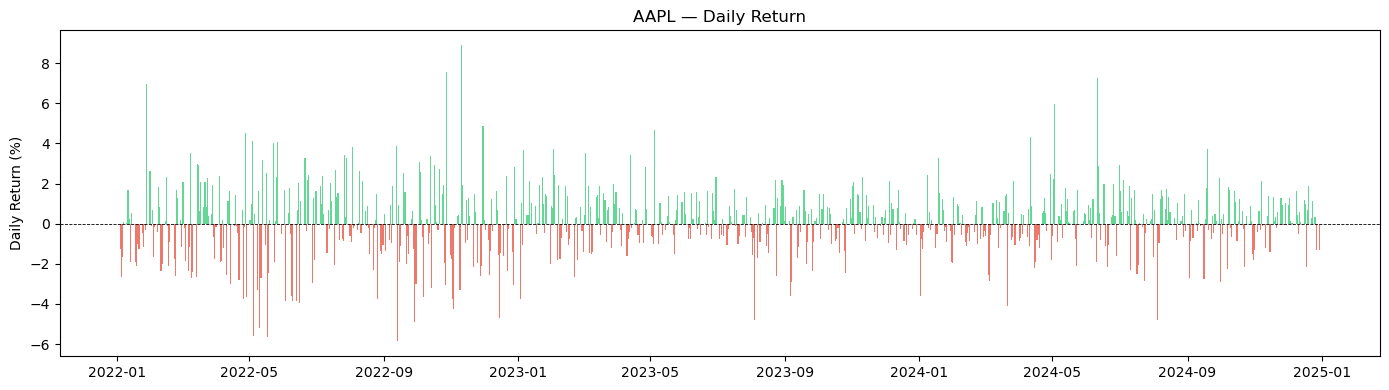

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df.index, df["Daily Return"] * 100,
       color=df["Daily Return"].apply(lambda x: "#2ecc71" if x >= 0 else "#e74c3c"),
       width=1, alpha=0.75)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"{ticker_symbol} — Daily Return")
ax.set_ylabel("Daily Return (%)")

plt.tight_layout()
plt.show()

# Green bar  = up day   | Red bar = down day
# Tall bars  = big move (earnings, news, macro)
# Tiny bars  = quiet day, low volatility

### Cumulative Return

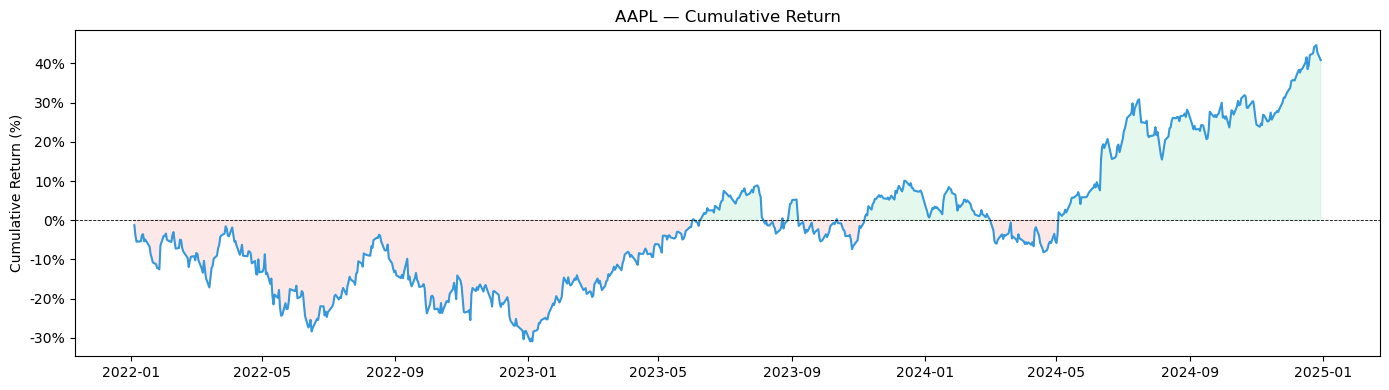

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["Cumulative Return"] * 100,
        color="#3498db", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.fill_between(df.index, df["Cumulative Return"] * 100, 0,
                where=df["Cumulative Return"] >= 0, alpha=0.12, color="#2ecc71")
ax.fill_between(df.index, df["Cumulative Return"] * 100, 0,
                where=df["Cumulative Return"] < 0,  alpha=0.12, color="#e74c3c")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title(f"{ticker_symbol} — Cumulative Return")
ax.set_ylabel("Cumulative Return (%)")

plt.tight_layout()
plt.show()

# Rising line       = stock gaining over the period
# Steep dip + climb = drawdown and recovery
# Green shading     = in profit from start date
# Red shading       = in loss from start date

## Volatility

In [17]:
WINDOW = 30 # How many days we're looking back at

df["Rolling Vol"]     = df["Daily Return"].rolling(WINDOW).std()
df["Ann. Rolling Vol"] = df["Rolling Vol"] * np.sqrt(252)

overall_ann_vol = df["Daily Return"].std() * np.sqrt(252) # Volatility of the whole period

print(f"Overall Annualised Volatility : {overall_ann_vol*100:.2f}%")
print(f"Rolling window                : {WINDOW} trading days")

Overall Annualised Volatility : 27.11%
Rolling window                : 30 trading days


### Rolling 30-Day Volatility (Daily Std)

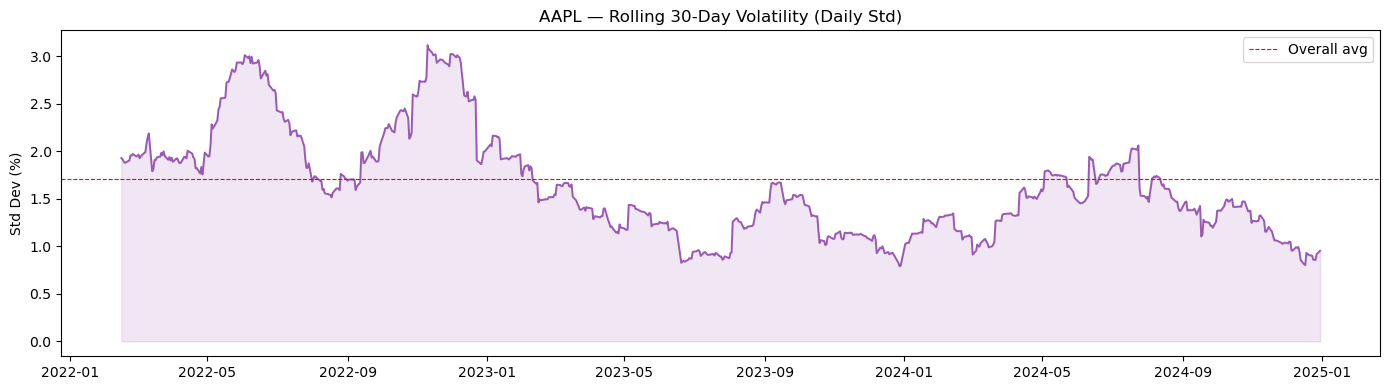

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["Rolling Vol"] * 100,
        color="#9b59b6", linewidth=1.4)
ax.fill_between(df.index, df["Rolling Vol"] * 100,
                alpha=0.15, color="#9b59b6")
ax.axhline(df["Daily Return"].std() * 100, color="red",
           linewidth=0.8, linestyle="--", label="Overall avg")
ax.set_title(f"{ticker_symbol} — Rolling {WINDOW}-Day Volatility (Daily Std)")
ax.set_ylabel("Std Dev (%)")
ax.legend()

plt.tight_layout()
plt.show()

# Peak    = turbulent period (rate hikes, earnings fear)
# Trough  = calm, low-uncertainty market
# Red line = your baseline — spikes above it are notable

### Annualised Rolling 30-Day Volatility

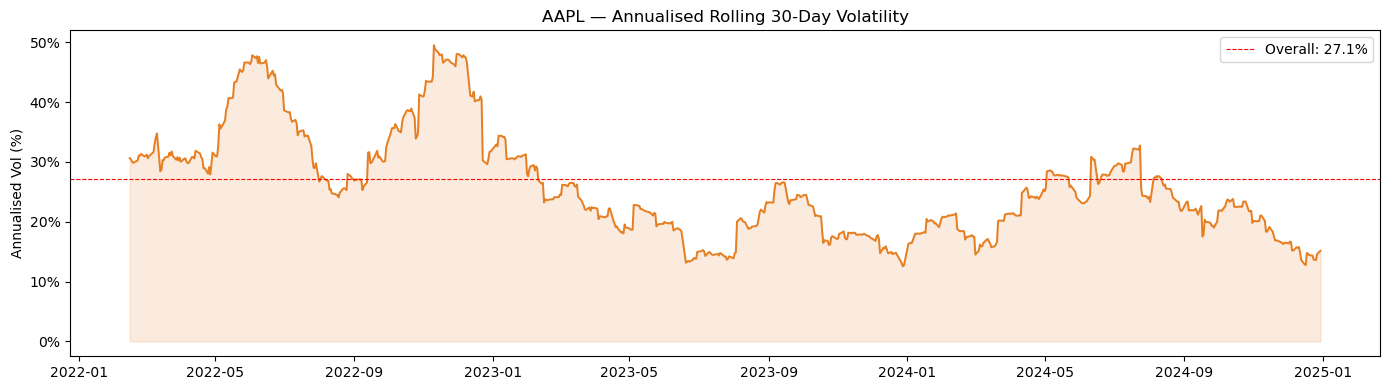

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["Ann. Rolling Vol"] * 100,
        color="#e67e22", linewidth=1.4)
ax.fill_between(df.index, df["Ann. Rolling Vol"] * 100,
                alpha=0.15, color="#e67e22")
ax.axhline(overall_ann_vol * 100, color="red",
           linewidth=0.8, linestyle="--",
           label=f"Overall: {overall_ann_vol*100:.1f}%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title(f"{ticker_symbol} — Annualised Rolling {WINDOW}-Day Volatility")
ax.set_ylabel("Annualised Vol (%)")
ax.legend()

plt.tight_layout()
plt.show()

# Scale is now yearly % — e.g. 30% means ±30% expected swing/year
# AAPL typically sits 25–35% annualised vol
# Spikes above 40%+ = exceptional turbulence
# This is the number used in options pricing

## Technical Indicators

### Calculations

In [20]:
# --- SMA ---
df["SMA_20"]  = df["Close"].rolling(20).mean() # Mean of each 20 day window
df["SMA_50"]  = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()

# --- EMA ---
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean() #ewm stands for Exponential Weighted Mean, span = 12 is the value for N in the formula k = 2/(N+1)
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean() # adjust = False uses the recursive formula (each day's EMA depends on the previous day's EMA)

# --- RSI ---
delta       = df["Close"].diff() # .diff() subtracts previous row from current row, todays close - yesterdays close
gain        = delta.clip(lower=0).rolling(14).mean() # .clip(lower=0) forces all negative values to 0. keeps only the up days, zeroes out the down days, rolling(14).mean() averages those gains over 14 days.
loss        = -delta.clip(upper=0).rolling(14).mean() # .clip(upper=0) forces all positive values to 0. keeps only the down days (negative numbers), zeroes out the up days. The - at the front flips the negatives to positives so the loss value is a positive number. Then average over 14 days.
df["RSI"]   = 100 - (100 / (1 + gain / loss)) # gain/loss = relative strength. 100/(1+RS) shrinks as RS grows. 100-... flips it so high RS gives high RSI

# --- MACD ---
df["MACD"]        = df["EMA_12"] - df["EMA_26"] # subtracts the two EMA columns already calculated. Positive = short-term momentum above long-term. Negative = below.
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean() # Takes the MACD column and applies another EMA, this time with span=9 to smooth it. This is the Signal Line. (applied to MACD values instead of price)
df["MACD_Hist"]   = df["MACD"] - df["MACD_Signal"] # Subtracts Signal from MACD. Positive = MACD is above Signal = bullish. Negative = MACD is below Signal = bearish. This is what the histogram bars represent.

# --- Bollinger Bands ---
df["BB_Mid"]   = df["Close"].rolling(20).mean() # Exactly the same as SMA_20 — the middle band is just the 20-day average.
df["BB_Std"]   = df["Close"].rolling(20).std() # measures how spread out the last 20 closing prices are around their mean. Small value = prices clustered tightly = bands narrow. Large value = prices spread out = bands wide.
df["BB_Upper"] = df["BB_Mid"] + 2 * df["BB_Std"] # Adds/subtracts 2 standard deviations from the middle band. 2 is the standard choice because statistically 95% of values fall within 2 standard deviations of the mean. 
df["BB_Lower"] = df["BB_Mid"] - 2 * df["BB_Std"] # You could use 1.5 for tighter bands or 2.5 for wider ones, but 2 is the convention.

print("Technical indicators calculated:")
print(df[["Close", "SMA_20", "SMA_50", "SMA_200",
          "RSI", "MACD", "MACD_Signal", "BB_Upper", "BB_Lower"]].tail())

Technical indicators calculated:
Price            Close      SMA_20      SMA_50     SMA_200        RSI  \
Date                                                                    
2024-12-23  253.883118  243.695760  234.001646  209.838112  73.865396   
2024-12-24  256.797180  244.955378  234.541779  210.266138  76.180662   
2024-12-26  257.612701  246.146867  235.047555  210.695863  76.812090   
2024-12-27  254.201355  247.174255  235.526234  211.118936  69.300632   
2024-12-30  250.829773  247.913715  235.930131  211.515887  58.382036   

Price           MACD  MACD_Signal    BB_Upper    BB_Lower  
Date                                                       
2024-12-23  5.740450     5.198232  256.772095  230.619424  
2024-12-24  6.040994     5.366785  257.981090  231.929666  
2024-12-26  6.272676     5.547963  259.228952  233.064783  
2024-12-27  6.110580     5.660486  259.319015  235.029494  
2024-12-30  5.644987     5.657387  258.954979  236.872450  


### SMA (Simple Moving Averages)

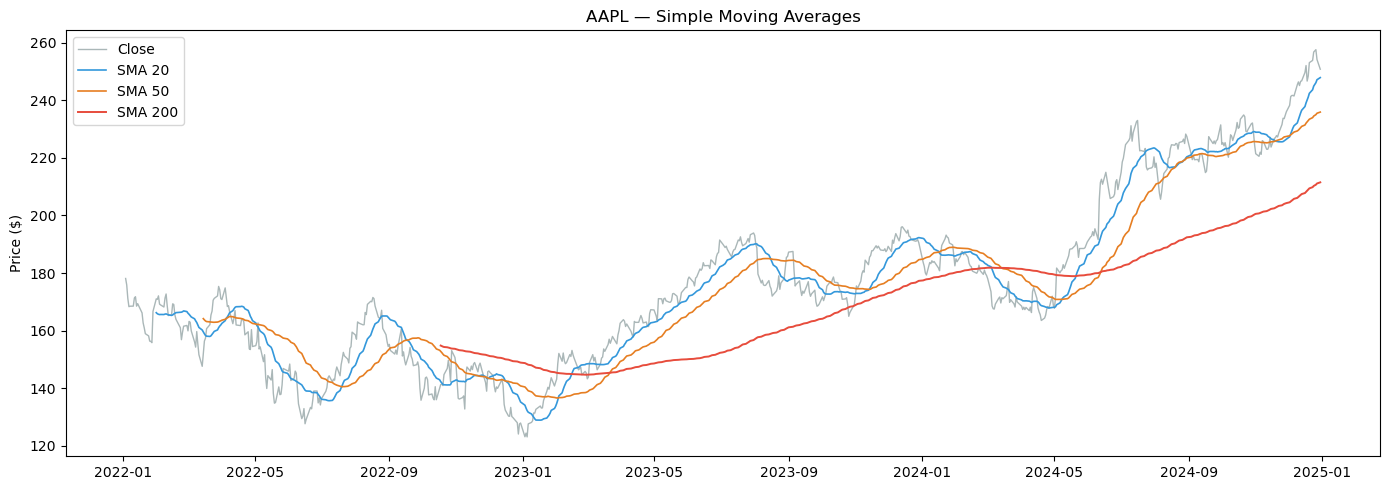

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["Close"],   color="#95a5a6", linewidth=1,   label="Close",   alpha=0.8)
ax.plot(df.index, df["SMA_20"],  color="#3498db", linewidth=1.2, label="SMA 20")
ax.plot(df.index, df["SMA_50"],  color="#e67e22", linewidth=1.2, label="SMA 50")
ax.plot(df.index, df["SMA_200"], color="#e74c3c", linewidth=1.4, label="SMA 200")

ax.set_title(f"{ticker_symbol} — Simple Moving Averages")
ax.set_ylabel("Price ($)")
ax.legend()

plt.tight_layout()
plt.show()

# Close above SMA_200       = long-term uptrend
# Close below SMA_200       = long-term downtrend
# SMA_20 crosses above SMA_50 = Golden Cross (bullish signal)
# SMA_20 crosses below SMA_50 = Death Cross  (bearish signal)
# SMAs bunching together    = trend losing strength, possible reversal

### EMA (Exponential Moving Averages) + Bollinger Bands

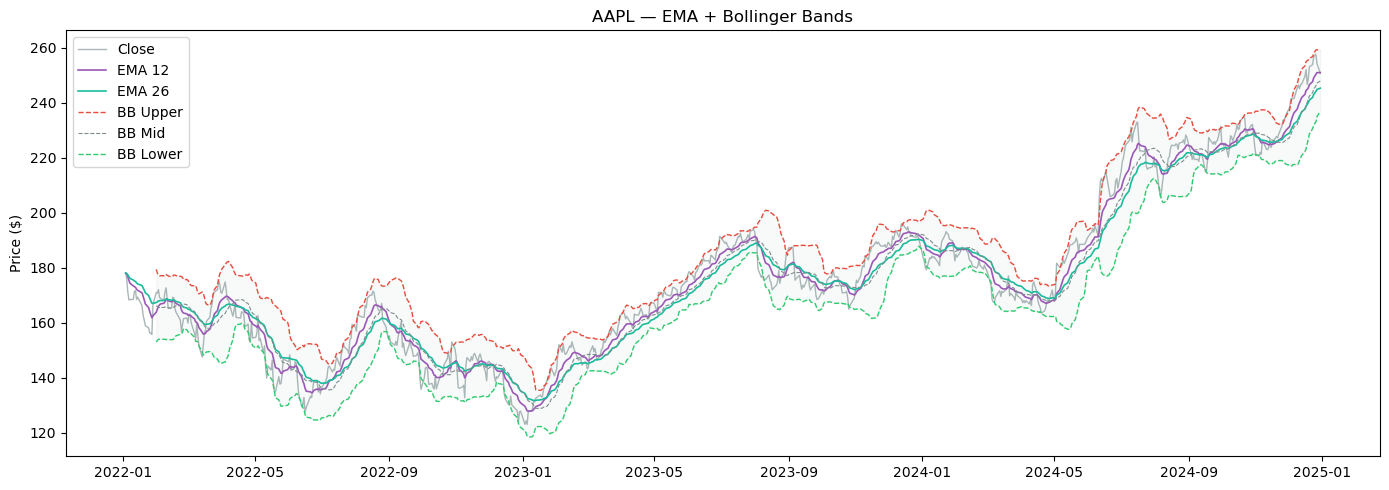

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["Close"],    color="#95a5a6", linewidth=1,   label="Close", alpha=0.8)
ax.plot(df.index, df["EMA_12"],   color="#9b59b6", linewidth=1.2, label="EMA 12")
ax.plot(df.index, df["EMA_26"],   color="#1abc9c", linewidth=1.2, label="EMA 26")
ax.plot(df.index, df["BB_Upper"], color="#e74c3c", linewidth=1,   label="BB Upper", linestyle="--")
ax.plot(df.index, df["BB_Mid"],   color="#7f8c8d", linewidth=0.8, label="BB Mid",   linestyle="--")
ax.plot(df.index, df["BB_Lower"], color="#2ecc71", linewidth=1,   label="BB Lower", linestyle="--")
ax.fill_between(df.index, df["BB_Upper"], df["BB_Lower"], alpha=0.05, color="#7f8c8d")

ax.set_title(f"{ticker_symbol} — EMA + Bollinger Bands")
ax.set_ylabel("Price ($)")
ax.legend()

plt.tight_layout()
plt.show()

# Price touching BB_Upper   = price at high end of normal range, may pull back
# Price touching BB_Lower   = price at low end of normal range, may bounce
# Bands narrow (squeeze)    = low volatility, big move likely coming
# Bands widen               = high volatility, market is unsettled
# EMA_12 above EMA_26       = short-term momentum is bullish
# EMA_12 below EMA_26       = short-term momentum is bearish

### RSI (Relative Strength Index)

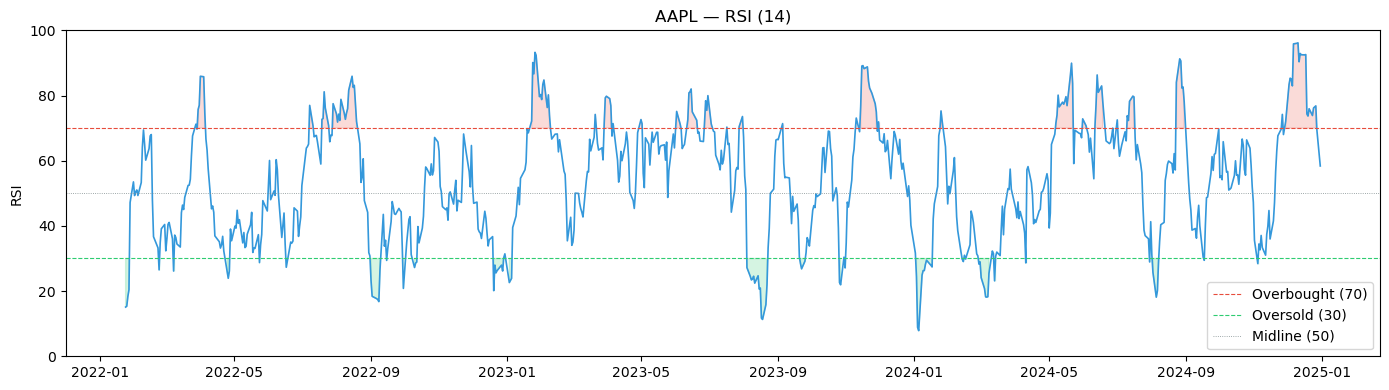

In [23]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["RSI"], color="#3498db", linewidth=1.2)
ax.axhline(70, color="#e74c3c", linewidth=0.8, linestyle="--", label="Overbought (70)")
ax.axhline(30, color="#2ecc71", linewidth=0.8, linestyle="--", label="Oversold (30)")
ax.axhline(50, color="#7f8c8d", linewidth=0.6, linestyle=":",  label="Midline (50)")
ax.fill_between(df.index, df["RSI"], 70,
                where=df["RSI"] >= 70, alpha=0.2, color="#e74c3c")
ax.fill_between(df.index, df["RSI"], 30,
                where=df["RSI"] <= 30, alpha=0.2, color="#2ecc71")
ax.set_ylim(0, 100)
ax.set_title(f"{ticker_symbol} — RSI (14)")
ax.set_ylabel("RSI")
ax.legend()

plt.tight_layout()
plt.show()

# RSI above 70 (red zone)   = stock has risen too fast, may be due for a pullback
# RSI below 30 (green zone) = stock has fallen too fast, may be due for a bounce
# RSI crossing 50 upward    = momentum turning bullish
# RSI crossing 50 downward  = momentum turning bearish
# RSI can stay overbought/oversold for long stretches in strong trends — not a
# guaranteed reversal signal on its own, use with other indicators

### MACD (Moving Average Convergence Divergence)

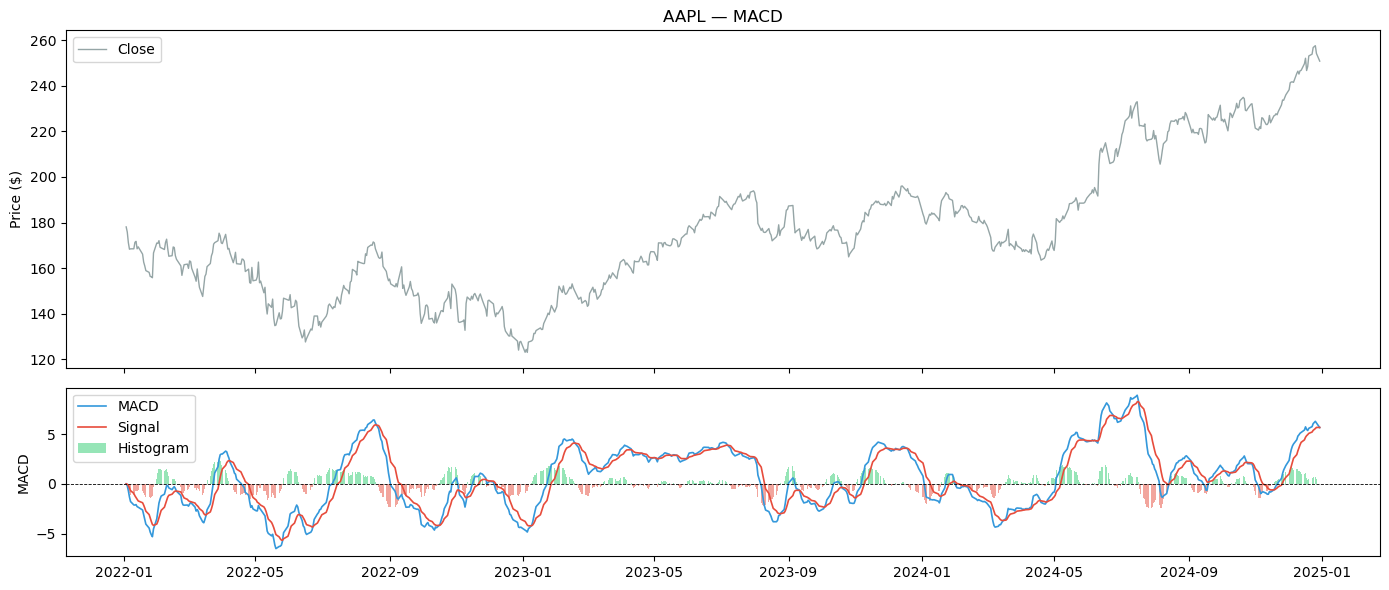

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

# Price + signal context on top
axes[0].plot(df.index, df["Close"], color="#95a5a6", linewidth=1, label="Close")
axes[0].set_ylabel("Price ($)")
axes[0].set_title(f"{ticker_symbol} — MACD")
axes[0].legend()

# MACD on bottom
axes[1].plot(df.index, df["MACD"],        color="#3498db", linewidth=1.2, label="MACD")
axes[1].plot(df.index, df["MACD_Signal"], color="#e74c3c", linewidth=1.2, label="Signal")
axes[1].bar(df.index, df["MACD_Hist"],
            color=df["MACD_Hist"].apply(lambda x: "#2ecc71" if x >= 0 else "#e74c3c"),
            width=1, alpha=0.5, label="Histogram")
axes[1].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[1].set_ylabel("MACD")
axes[1].legend()

plt.tight_layout()
plt.show()

# MACD crosses above Signal  = bullish crossover, momentum shifting up
# MACD crosses below Signal  = bearish crossover, momentum shifting down
# Histogram above zero       = MACD > Signal, bullish momentum
# Histogram below zero       = MACD < Signal, bearish momentum
# Histogram bars shrinking   = momentum is fading, possible crossover soon
# MACD diverging from price  = price making new highs but MACD isn't = warning sign

## Volume Analysis

### Volume Calculations

In [25]:
# --- Average Volume ---
df["Avg_Volume"] = df["Volume"].rolling(20).mean()

# --- Volume Spike ---
df["Volume_Spike"] = df["Volume"] / df["Avg_Volume"]  # ratio vs average
# anything above 2.0 = more than double average = significant spike

# --- OBV ---
obv = []
obv_value = 0

for i in range(len(df)):
    if i == 0:
        obv.append(0)
    elif df["Close"].iloc[i] > df["Close"].iloc[i - 1]:
        obv_value += df["Volume"].iloc[i]   # up day → add volume
        obv.append(obv_value)
    elif df["Close"].iloc[i] < df["Close"].iloc[i - 1]:
        obv_value -= df["Volume"].iloc[i]   # down day → subtract volume
        obv.append(obv_value)
    else:
        obv.append(obv_value)               # unchanged day → no change

df["OBV"] = obv

print(df[["Close", "Volume", "Avg_Volume", "Volume_Spike", "OBV"]].tail(10))

Price            Close     Volume  Avg_Volume  Volume_Spike         OBV
Date                                                                   
2024-12-16  249.676071   51694800  42354720.0      1.220520  1170568700
2024-12-17  252.102829   51356400  42690855.0      1.202984  1221925100
2024-12-18  246.702347   56774100  43718970.0      1.298615  1165151000
2024-12-19  248.432877   60882300  45004605.0      1.352802  1226033300
2024-12-20  253.107346  147495300  50273955.0      2.933831  1373528600
2024-12-23  253.883118   40858800  50408480.0      0.810554  1414387400
2024-12-24  256.797180   23234700  47062575.0      0.493698  1437622100
2024-12-26  257.612701   27237100  46125120.0      0.590505  1464859200
2024-12-27  254.201355   42355300  46567965.0      0.909537  1422503900
2024-12-30  250.829773   35557500  46921770.0      0.757804  1386946400


### Average volume + volume spike plot

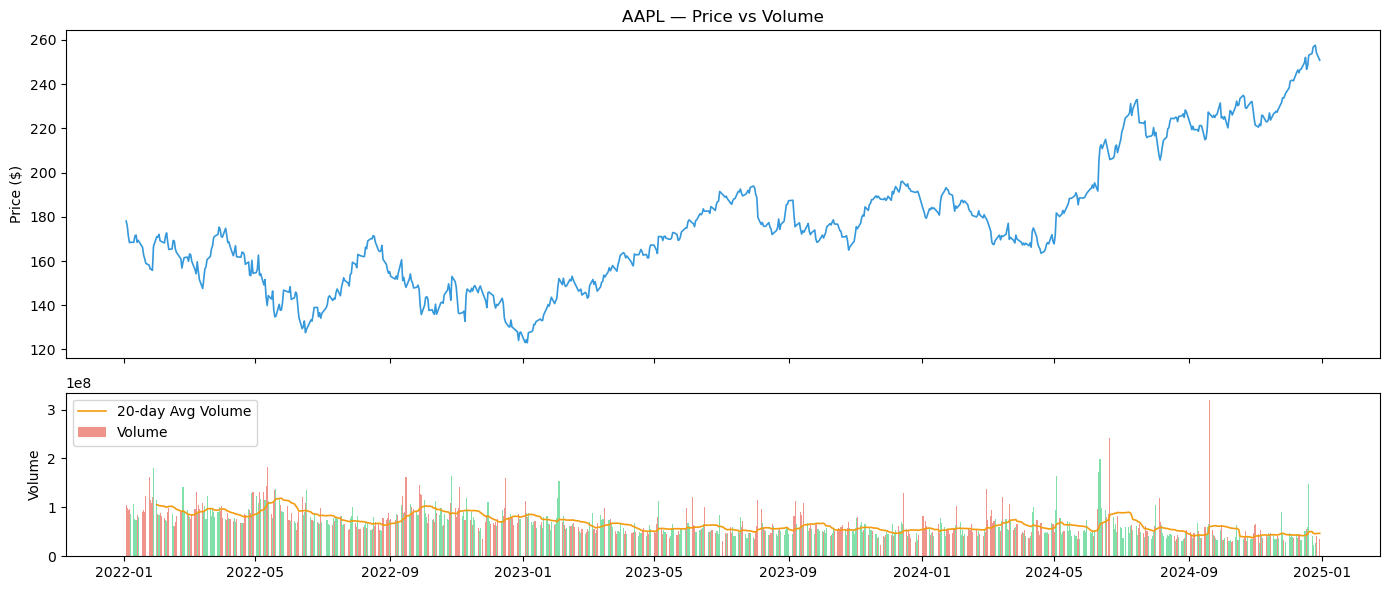

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

# Price on top for context
axes[0].plot(df.index, df["Close"], color="#3498db", linewidth=1.2)
axes[0].set_title(f"{ticker_symbol} — Price vs Volume")
axes[0].set_ylabel("Price ($)")

# Volume bars + average line on bottom
axes[1].bar(df.index, df["Volume"],
            color=df["Close"].pct_change().apply(lambda x: "#2ecc71" if x >= 0 else "#e74c3c"),
            width=1, alpha=0.6, label="Volume")
axes[1].plot(df.index, df["Avg_Volume"],
             color="#f39c12", linewidth=1.2, label="20-day Avg Volume")
axes[1].set_ylabel("Volume")
axes[1].legend()

plt.tight_layout()
plt.show()

# Green bar       = volume on an up day
# Red bar         = volume on a down day
# Bar well above orange line  = unusually high volume, significant event
# Bar well below orange line  = unusually quiet day, weak conviction
# High volume up day          = strong buying pressure, move is real
# High volume down day        = strong selling pressure, move is real
# Low volume up day           = weak move, may not sustain
# Low volume down day         = weak selling, may not sustain

### Volume spike plot

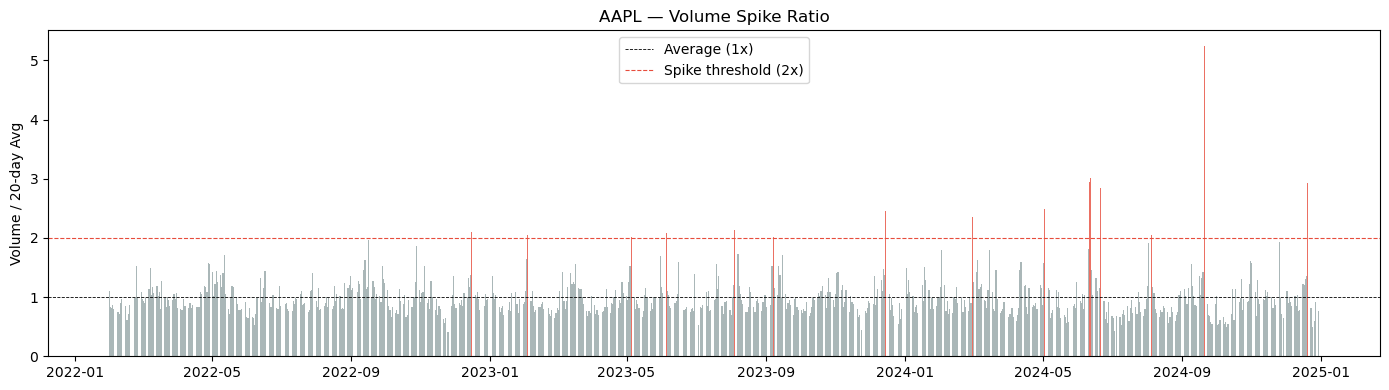

In [27]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df.index, df["Volume_Spike"],
       color=df["Volume_Spike"].apply(lambda x: "#e74c3c" if x >= 2 else "#95a5a6"),
       width=1, alpha=0.8)
ax.axhline(1.0, color="black",   linewidth=0.6, linestyle="--", label="Average (1x)")
ax.axhline(2.0, color="#e74c3c", linewidth=0.8, linestyle="--", label="Spike threshold (2x)")
ax.set_title(f"{ticker_symbol} — Volume Spike Ratio")
ax.set_ylabel("Volume / 20-day Avg")
ax.legend()

plt.tight_layout()
plt.show()

# Y-axis is a ratio, not raw volume:
#   1.0 = exactly average volume
#   2.0 = double the average = spike
#   3.0 = triple the average = major event

# Red bars above 2x → significant spike, something happened that day
# Gray bars        → normal volume, nothing unusual
# Spike with price up   → strong buying, move is confirmed
# Spike with price down → strong selling, move is confirmed
# Spike with no price move → accumulation or distribution happening quietly

### OBV (On-balance volume) plot

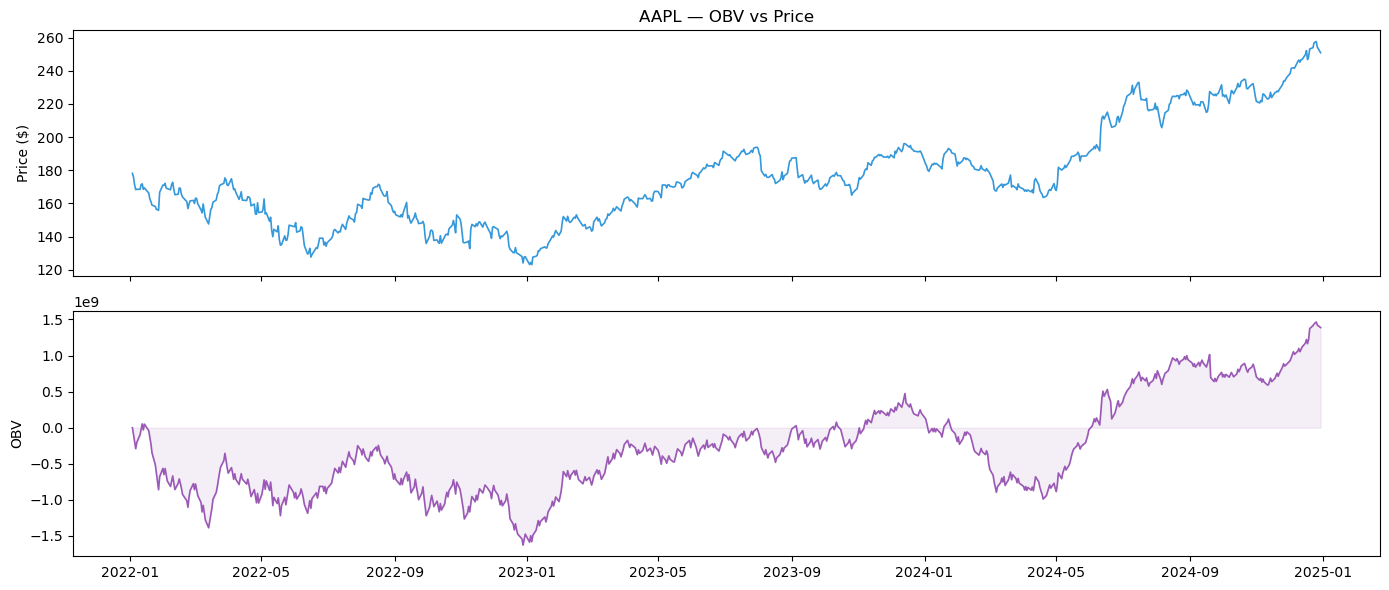

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={"height_ratios": [1, 1]})

# Price on top
axes[0].plot(df.index, df["Close"], color="#3498db", linewidth=1.2)
axes[0].set_title(f"{ticker_symbol} — OBV vs Price")
axes[0].set_ylabel("Price ($)")

# OBV on bottom
axes[1].plot(df.index, df["OBV"], color="#9b59b6", linewidth=1.2)
axes[1].fill_between(df.index, df["OBV"], alpha=0.1, color="#9b59b6")
axes[1].set_ylabel("OBV")

plt.tight_layout()
plt.show()

# OBV rising + price rising  → volume confirming uptrend, healthy move
# OBV falling + price falling→ volume confirming downtrend, healthy move
# OBV rising + price flat    → accumulation, big buyers loading quietly
#                               price breakout likely coming soon
# OBV falling + price flat   → distribution, big sellers offloading quietly
#                               price breakdown likely coming soon
# OBV falling + price rising → divergence, rally not backed by volume
#                               move may be fake, reversal risk is high
# OBV rising + price falling → divergence, selloff not backed by volume
#                               may be false breakdown, bounce possible

## Multi-Stock Comparisons

In [29]:
# --- Download multiple stocks + S&P 500 ---
symbols = ["AAPL", "MSFT", "GOOGL", "SPY"]  # SPY = S&P 500 ETF

raw = yf.download(symbols, start="2022-01-01", end="2024-12-31")["Close"]

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# --- Normalized Price (index all to 100 at start) ---
normalized = (raw / raw.iloc[0]) * 100

# --- Daily Returns for each stock ---
returns = raw.pct_change().dropna()

# --- Correlation Matrix ---
corr_matrix = returns.corr()

# --- Beta (each stock vs SPY) ---
market_returns = returns["SPY"]
betas = {}

for stock in ["AAPL", "MSFT", "GOOGL"]:
    cov   = returns[stock].cov(market_returns)
    var   = market_returns.var()
    betas[stock] = cov / var

C:\Users\rasul\AppData\Local\Temp\ipykernel_36016\3748949430.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(symbols, start="2022-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  4 of 4 completed


### Normalized Price Chart

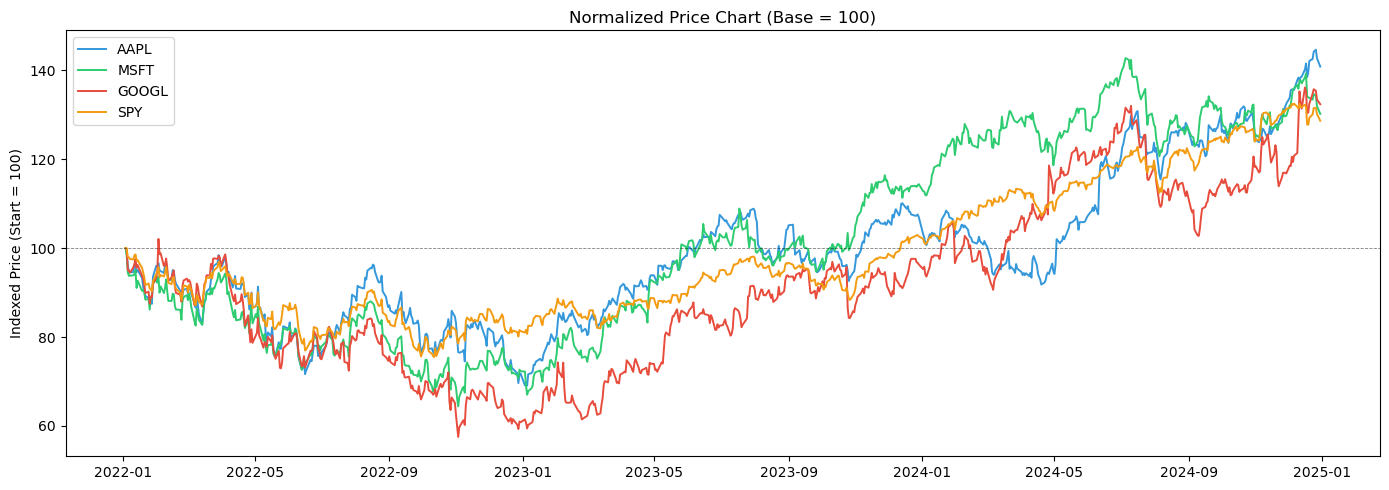

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = {"AAPL": "#3498db", "MSFT": "#2ecc71", "GOOGL": "#e74c3c", "SPY": "#f39c12"}

for symbol in symbols:
    ax.plot(normalized.index, normalized[symbol],
            label=symbol, color=colors[symbol], linewidth=1.4)

ax.axhline(100, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_title("Normalized Price Chart (Base = 100)")
ax.set_ylabel("Indexed Price (Start = 100)")
ax.legend()

plt.tight_layout()
plt.show()

# All stocks start at 100 on day one — removes price bias
# Line at 150 = stock is up 50% from start date
# Line at 80  = stock is down 20% from start date
# Line above SPY (yellow) = outperforming the market
# Line below SPY (yellow) = underperforming the market
# Stocks moving together  = highly correlated
# Stocks diverging        = different drivers, low correlation

### Correlation Matrix

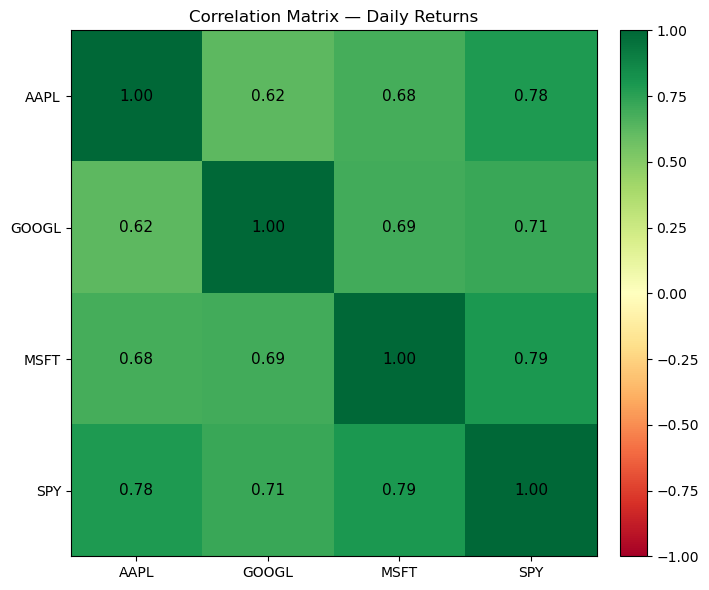

In [31]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(7, 6))

cmap = plt.cm.RdYlGn
im   = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=11,
                color="black")

ax.set_title("Correlation Matrix — Daily Returns")

plt.tight_layout()
plt.show()

# Each cell = correlation between two stocks (-1 to +1)
# Diagonal is always 1.0 (stock perfectly correlates with itself)
# Green (close to 1)  = stocks move together strongly
# Red   (close to -1) = stocks move in opposite directions
# Yellow (close to 0) = stocks move independently of each other
# High correlation with SPY = stock follows the market closely
# Low correlation with SPY  = stock has its own independent drivers

Beta vs S&P 500

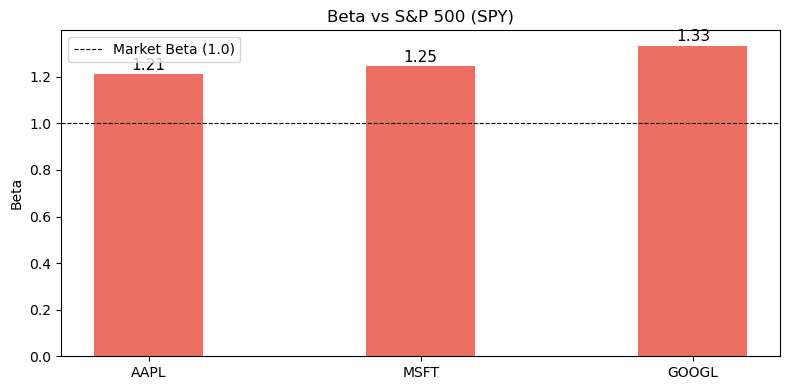

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

stocks = list(betas.keys())
values = list(betas.values())
colors = ["#2ecc71" if b < 1 else "#e74c3c" for b in values]

ax.bar(stocks, values, color=colors, alpha=0.8, width=0.4)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="Market Beta (1.0)")
ax.axhline(0.0, color="gray",  linewidth=0.5, linestyle=":")

for i, (stock, val) in enumerate(zip(stocks, values)):
    ax.text(i, val + 0.02, f"{val:.2f}", ha="center", fontsize=11)

ax.set_title("Beta vs S&P 500 (SPY)")
ax.set_ylabel("Beta")
ax.legend()

plt.tight_layout()
plt.show()

# Beta = 1.0  → moves exactly with the market
# Beta > 1.0  → more volatile than market (red bar)
#               e.g. Beta 1.3 = moves 30% more than market
# Beta < 1.0  → less volatile than market (green bar)
#               e.g. Beta 0.7 = moves 30% less than market
# Beta < 0    → moves opposite to market (rare, e.g. gold stocks)
# High beta   → higher risk, higher potential return
# Low beta    → lower risk, more stable, defensive stock

## Fundamental Metrics

In [33]:
# All fundamental data comes from ticker.info (no df needed)
ticker=yf.Ticker("AAPL")
info = ticker.info

# --- P/E Ratio ---
pe_trailing = info.get("trailingPE", "N/A")
pe_forward  = info.get("forwardPE", "N/A")

# --- P/B Ratio ---
pb_ratio    = info.get("priceToBook", "N/A")

# --- EPS ---
eps_trailing = info.get("trailingEps", "N/A")
eps_forward  = info.get("forwardEps", "N/A")

# --- Dividend Yield ---
div_yield    = info.get("dividendYield", 0)
div_rate     = info.get("dividendRate", "N/A")

# --- Revenue & Net Income ---
financials   = ticker.financials  # annual income statement
revenue      = financials.loc["Total Revenue"]
net_income   = financials.loc["Net Income"]

# --- Revenue & Net Income Growth (YoY) ---
rev_growth   = revenue.pct_change(-1)   # -1 = compare to previous year
ni_growth    = net_income.pct_change(-1)

print("=" * 50)
print(f"P/E  (Trailing)  : {pe_trailing}")
print(f"P/E  (Forward)   : {pe_forward}")
print(f"P/B  Ratio       : {pb_ratio}")
print(f"EPS  (Trailing)  : ${eps_trailing}")
print(f"EPS  (Forward)   : ${eps_forward}")
print(f"Dividend Yield   : {div_yield*100:.2f}%")
print(f"Dividend Rate    : ${div_rate}")
print("=" * 50)
print("\nAnnual Revenue:")
print(revenue.apply(lambda x: f"${x/1e9:.2f}B"))
print("\nRevenue Growth (YoY):")
print(rev_growth.apply(lambda x: f"{x*100:.1f}%" if isinstance(x, float) else "N/A"))
print("\nAnnual Net Income:")
print(net_income.apply(lambda x: f"${x/1e9:.2f}B"))
print("\nNet Income Growth (YoY):")
print(ni_growth.apply(lambda x: f"{x*100:.1f}%" if isinstance(x, float) else "N/A"))
print("=" * 50)

P/E  (Trailing)  : 32.16603
P/E  (Forward)   : 27.241413
P/B  Ratio       : 42.312435
EPS  (Trailing)  : $7.89
EPS  (Forward)   : $9.31633
Dividend Yield   : 41.00%
Dividend Rate    : $1.04

Annual Revenue:
2025-09-30    $416.16B
2024-09-30    $391.04B
2023-09-30    $383.29B
2022-09-30    $394.33B
2021-09-30       $nanB
Name: Total Revenue, dtype: object

Revenue Growth (YoY):
2025-09-30     6.4%
2024-09-30     2.0%
2023-09-30    -2.8%
2022-09-30     0.0%
2021-09-30     nan%
Name: Total Revenue, dtype: object

Annual Net Income:
2025-09-30    $112.01B
2024-09-30     $93.74B
2023-09-30     $97.00B
2022-09-30     $99.80B
2021-09-30       $nanB
Name: Net Income, dtype: object

Net Income Growth (YoY):
2025-09-30    19.5%
2024-09-30    -3.4%
2023-09-30    -2.8%
2022-09-30     0.0%
2021-09-30     nan%
Name: Net Income, dtype: object


C:\Users\rasul\AppData\Local\Temp\ipykernel_36016\4272527528.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rev_growth   = revenue.pct_change(-1)   # -1 = compare to previous year
C:\Users\rasul\AppData\Local\Temp\ipykernel_36016\4272527528.py:27: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ni_growth    = net_income.pct_change(-1)


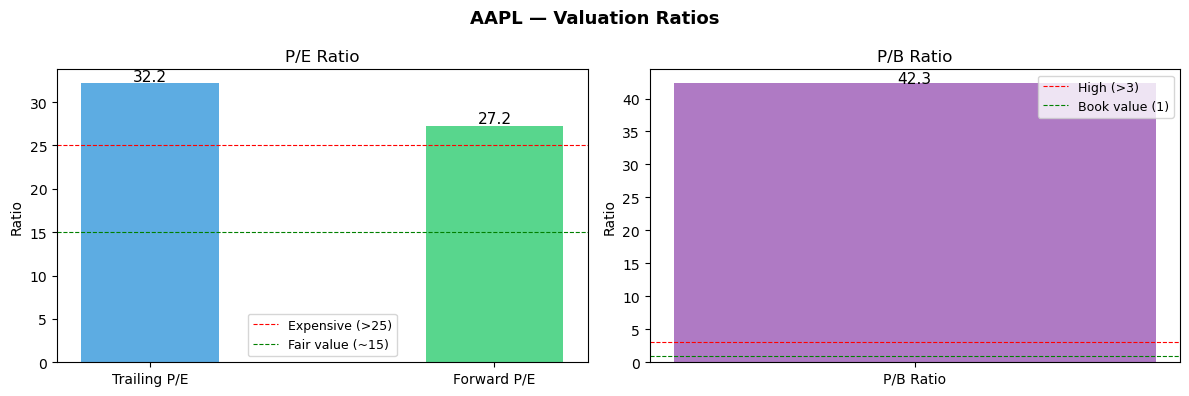

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# P/E bar
pe_values  = [pe_trailing, pe_forward]
pe_labels  = ["Trailing P/E", "Forward P/E"]
pe_colors  = ["#3498db", "#2ecc71"]
axes[0].bar(pe_labels, pe_values, color=pe_colors, alpha=0.8, width=0.4)
axes[0].axhline(25, color="red",  linewidth=0.8, linestyle="--", label="Expensive (>25)")
axes[0].axhline(15, color="green",linewidth=0.8, linestyle="--", label="Fair value (~15)")
for i, val in enumerate(pe_values):
    axes[0].text(i, val + 0.3, f"{val:.1f}", ha="center", fontsize=11)
axes[0].set_title("P/E Ratio")
axes[0].set_ylabel("Ratio")
axes[0].legend(fontsize=9)

# P/B bar
axes[1].bar(["P/B Ratio"], [pb_ratio], color="#9b59b6", alpha=0.8, width=0.3)
axes[1].axhline(3.0, color="red",  linewidth=0.8, linestyle="--", label="High (>3)")
axes[1].axhline(1.0, color="green",linewidth=0.8, linestyle="--", label="Book value (1)")
axes[1].text(0, pb_ratio + 0.05, f"{pb_ratio:.1f}", ha="center", fontsize=11)
axes[1].set_title("P/B Ratio")
axes[1].set_ylabel("Ratio")
axes[1].legend(fontsize=9)

fig.suptitle(f"{ticker_symbol} — Valuation Ratios", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# P/E below 15  → cheap relative to earnings, possibly undervalued
# P/E 15-25     → fair value range for most stocks
# P/E above 25  → expensive, market expects high future growth
# P/E very high → either high growth stock or overvalued, check forward P/E
# Forward < Trailing P/E → earnings expected to grow, good sign
# Forward > Trailing P/E → earnings expected to shrink, warning sign
# P/B below 1   → trading below asset value, potentially very cheap
# P/B 1-3       → normal range
# P/B above 3   → market paying heavy premium over assets

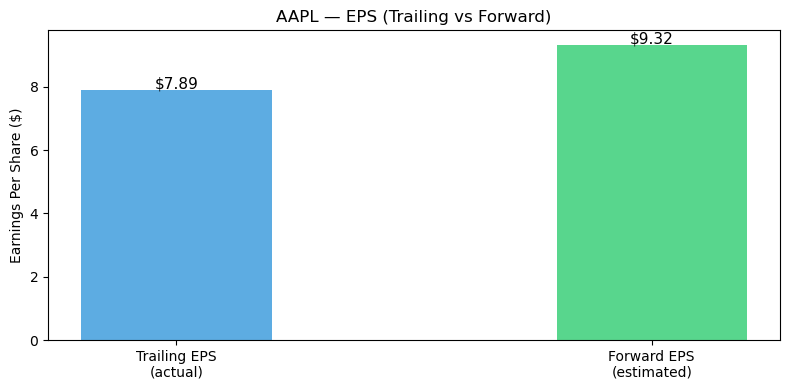

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))

eps_labels = ["Trailing EPS\n(actual)", "Forward EPS\n(estimated)"]
eps_values = [eps_trailing, eps_forward]
eps_colors = ["#3498db", "#2ecc71" if eps_forward > eps_trailing else "#e74c3c"]

bars = ax.bar(eps_labels, eps_values, color=eps_colors, alpha=0.8, width=0.4)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
for i, val in enumerate(eps_values):
    ax.text(i, val + 0.05, f"${val:.2f}", ha="center", fontsize=11)

ax.set_title(f"{ticker_symbol} — EPS (Trailing vs Forward)")
ax.set_ylabel("Earnings Per Share ($)")

plt.tight_layout()
plt.show()

# EPS positive         → company is profitable
# EPS negative         → company is losing money
# Forward > Trailing   → earnings expected to grow (green bar)
# Forward < Trailing   → earnings expected to shrink (red bar)
# EPS growing over time→ company becoming more profitable per share

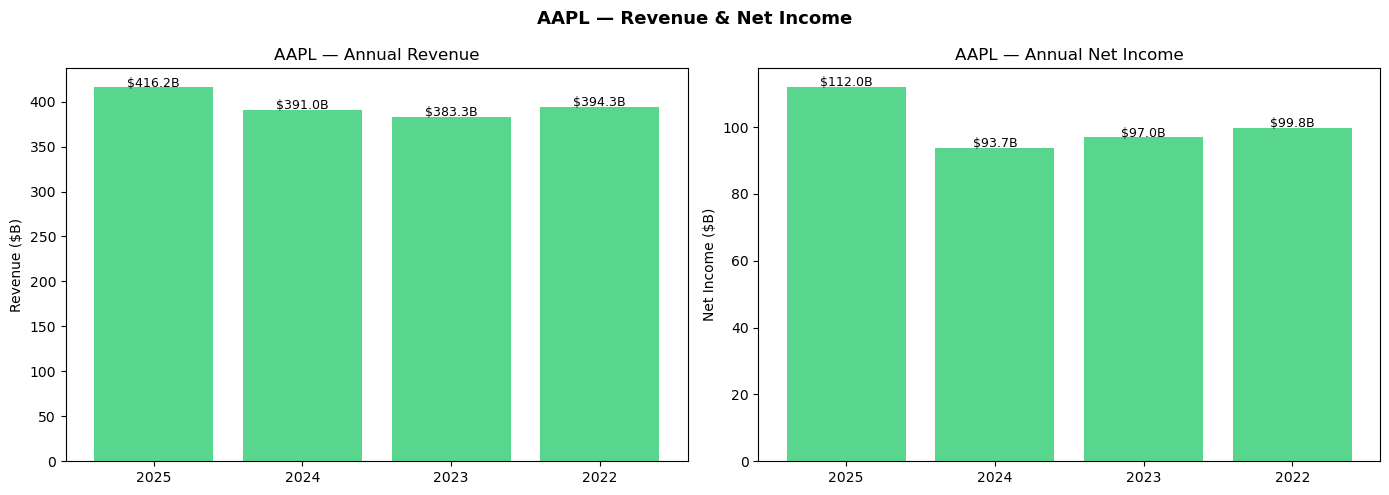

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years        = [str(d.year) for d in revenue.index]
rev_billions = [v / 1e9 for v in revenue.values]
ni_billions  = [v / 1e9 for v in net_income.values]

# Revenue bars
axes[0].bar(years, rev_billions,
            color=["#2ecc71" if v >= 0 else "#e74c3c" for v in rev_billions],
            alpha=0.8)
axes[0].set_title(f"{ticker_symbol} — Annual Revenue")
axes[0].set_ylabel("Revenue ($B)")
for i, val in enumerate(rev_billions):
    axes[0].text(i, val + 0.5, f"${val:.1f}B", ha="center", fontsize=9)

# Net income bars
axes[1].bar(years, ni_billions,
            color=["#2ecc71" if v >= 0 else "#e74c3c" for v in ni_billions],
            alpha=0.8)
axes[1].set_title(f"{ticker_symbol} — Annual Net Income")
axes[1].set_ylabel("Net Income ($B)")
for i, val in enumerate(ni_billions):
    axes[1].text(i, val + 0.2, f"${val:.1f}B", ha="center", fontsize=9)

fig.suptitle(f"{ticker_symbol} — Revenue & Net Income", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Both bars growing year on year → business is expanding, healthy
# Revenue growing, net income flat → costs rising, margin pressure
# Revenue flat, net income growing → becoming more efficient
# Net income negative              → company losing money
# Revenue shrinking                → business is contracting, warning sign

## Summary

In [37]:
latest       = df.iloc[-1]   # most recent row
close        = latest["Close"]

# --- Trend ---
sma200       = latest["SMA_200"]
sma50        = latest["SMA_50"]
sma20        = latest["SMA_20"]

if close > sma200 and sma20 > sma50:
    trend = "Bullish"
elif close < sma200 and sma20 < sma50:
    trend = "Bearish"
else:
    trend = "Mixed"

# --- Momentum ---
rsi          = latest["RSI"]
macd         = latest["MACD"]
macd_signal  = latest["MACD_Signal"]

if rsi > 50 and macd > macd_signal:
    momentum = "Strong"
elif rsi < 50 and macd < macd_signal:
    momentum = "Weak"
else:
    momentum = "Mixed"

# --- Volatility ---
ann_vol      = df["Daily Return"].std() * np.sqrt(252) * 100

if ann_vol < 20:
    vol_label = "Low"
elif ann_vol < 35:
    vol_label = "Moderate"
else:
    vol_label = "High"

# --- Volume / OBV ---
obv_trend    = df["OBV"].iloc[-1] - df["OBV"].iloc[-20]  # OBV change over last 20 days
price_trend  = df["Close"].iloc[-1] - df["Close"].iloc[-20]

if obv_trend > 0 and price_trend > 0:
    volume_label = "Confirming uptrend"
elif obv_trend < 0 and price_trend < 0:
    volume_label = "Confirming downtrend"
elif obv_trend > 0 and price_trend < 0:
    volume_label = "Divergence — OBV rising, price falling (bullish)"
elif obv_trend < 0 and price_trend > 0:
    volume_label = "Divergence — OBV falling, price rising (bearish)"
else:
    volume_label = "Neutral"

# --- Valuation ---
pe           = info.get("trailingPE", None)
forward_pe   = info.get("forwardPE", None)

if pe is None:
    val_label = "N/A"
elif pe < 15:
    val_label = "Cheap"
elif pe < 25:
    val_label = "Fair"
else:
    val_label = "Expensive"

# --- Fundamentals ---
try:
    rev        = ticker.financials.loc["Total Revenue"]
    ni         = ticker.financials.loc["Net Income"]
    rev_g      = (rev.iloc[0] - rev.iloc[1]) / abs(rev.iloc[1]) * 100
    ni_g       = (ni.iloc[0] - ni.iloc[1])  / abs(ni.iloc[1])  * 100

    if rev_g > 5 and ni_g > 5:
        fund_label = "Strong"
    elif rev_g > 0 and ni_g > 0:
        fund_label = "Moderate"
    elif rev_g < 0 and ni_g < 0:
        fund_label = "Weak"
    else:
        fund_label = "Mixed"

    fund_detail = f"Revenue {rev_g:+.1f}%  |  Net Income {ni_g:+.1f}%"
except:
    fund_label  = "N/A"
    fund_detail = "Financials unavailable"

# --- Beta ---
market_ret   = returns["SPY"]
stock_ret    = returns["AAPL"]
beta_val     = stock_ret.cov(market_ret) / market_ret.var()

if beta_val > 1.2:
    beta_label = "High — more volatile than market"
elif beta_val < 0.8:
    beta_label = "Low — less volatile than market"
else:
    beta_label = "Moderate — moves with market"

# --- RSI label ---
if rsi >= 70:
    rsi_label = "Overbought"
elif rsi <= 30:
    rsi_label = "Oversold"
elif rsi >= 55:
    rsi_label = "Bullish territory"
elif rsi <= 45:
    rsi_label = "Bearish territory"
else:
    rsi_label = "Neutral"

# --- BB Position ---
bb_upper     = latest["BB_Upper"]
bb_lower     = latest["BB_Lower"]
bb_mid       = latest["BB_Mid"]

if close >= bb_upper:
    bb_label = "At upper band — overbought range"
elif close <= bb_lower:
    bb_label = "At lower band — oversold range"
elif close > bb_mid:
    bb_label = "Above midline — mild bullish"
else:
    bb_label = "Below midline — mild bearish"

# --- Overall verdict ---
signals = {
    "bullish": 0,
    "bearish": 0
}

# Trend carries more weight — it's the strongest signal
if trend == "Bullish":   signals["bullish"] += 2
if trend == "Bearish":   signals["bearish"] += 2

# Momentum
if momentum == "Strong": signals["bullish"] += 1
if momentum == "Weak":   signals["bearish"] += 1

# RSI — only vote at extremes, ignore middle ground
if rsi >= 70:            signals["bearish"] += 1   # overbought, caution
if rsi <= 30:            signals["bullish"] += 1   # oversold, opportunity
# RSI between 30-70 = no vote, not extreme enough

# MACD — single vote, less weight than trend
if macd > macd_signal:   signals["bullish"] += 1
if macd < macd_signal:   signals["bearish"] += 1

# Volume confirmation
if "confirming uptrend"   in volume_label.lower(): signals["bullish"] += 1
if "confirming downtrend" in volume_label.lower(): signals["bearish"] += 1
if "bearish" in volume_label.lower():              signals["bearish"] += 1
if "bullish" in volume_label.lower() and "divergence" in volume_label.lower():
                                                   signals["bullish"] += 1

# Fundamentals vote
if fund_label == "Strong":  signals["bullish"] += 1
if fund_label == "Weak":    signals["bearish"] += 1

if signals["bullish"] > signals["bearish"] + 1:
    verdict = "Bullish — multiple indicators aligned"
elif signals["bearish"] > signals["bullish"] + 1:
    verdict = "Bearish — multiple indicators aligned"
else:
    verdict = "Neutral / Mixed — no clear directional signal"

# ============================================================
# PRINT SCORECARD
# ============================================================

div = "─" * 52

print(f"\n{div}")
print(f"  {ticker_symbol} ({info.get('longName', '')}) — Analysis Scorecard")
print(f"{div}")
print(f"  Current Price     : ${close:.2f}")
print(f"{div}")
print(f"  TREND")
print(f"    Direction       : {trend}")
print(f"    Price vs SMA200 : {'Above' if close > sma200 else 'Below'}  (${sma200:.2f})")
print(f"    SMA20 vs SMA50  : {'SMA20 above — bullish' if sma20 > sma50 else 'SMA20 below — bearish'}")
print(f"{div}")
print(f"  MOMENTUM")
print(f"    Strength        : {momentum}")
print(f"    RSI (14)        : {rsi:.1f}  →  {rsi_label}")
print(f"    MACD            : {'Above signal — bullish' if macd > macd_signal else 'Below signal — bearish'}")
print(f"    Bollinger Band  : {bb_label}")
print(f"{div}")
print(f"  VOLATILITY")
print(f"    Ann. Volatility : {ann_vol:.1f}%  →  {vol_label}")
print(f"    Beta vs Market  : {beta_val:.2f}  →  {beta_label}")
print(f"{div}")
print(f"  VOLUME")
print(f"    OBV Signal      : {volume_label}")
print(f"{div}")
print(f"  VALUATION")
print(f"    Trailing P/E    : {pe:.1f}")
print(f"    Forward P/E     : {forward_pe:.1f}")
print(f"    Assessment      : {val_label}")
print(f"{div}")
print(f"  FUNDAMENTALS")
print(f"    Health          : {fund_label}")
print(f"    Detail          : {fund_detail}")
print(f"{div}")
print(f"  OVERALL VERDICT   : {verdict}")
print(f"{div}\n")


────────────────────────────────────────────────────
  AAPL (Apple Inc.) — Analysis Scorecard
────────────────────────────────────────────────────
  Current Price     : $250.83
────────────────────────────────────────────────────
  TREND
    Direction       : Bullish
    Price vs SMA200 : Above  ($211.52)
    SMA20 vs SMA50  : SMA20 above — bullish
────────────────────────────────────────────────────
  MOMENTUM
    Strength        : Mixed
    RSI (14)        : 58.4  →  Bullish territory
    MACD            : Below signal — bearish
    Bollinger Band  : Above midline — mild bullish
────────────────────────────────────────────────────
  VOLATILITY
    Ann. Volatility : 27.1%  →  Moderate
    Beta vs Market  : 1.21  →  High — more volatile than market
────────────────────────────────────────────────────
  VOLUME
    OBV Signal      : Confirming uptrend
────────────────────────────────────────────────────
  VALUATION
    Trailing P/E    : 32.2
    Forward P/E     : 27.2
    Assessment    

## Backtesting

In [40]:
# Step 1: Generate trading signals based on SMA crossover
# We already have SMA20 and SMA50 from Section 5
# If SMA20 > SMA50, we're in an uptrend → hold the stock (signal = 1)
# If SMA20 < SMA50, we're in a downtrend → stay out (signal = 0)

df['Signal'] = 0  # start with everything as 0 (out of market)
df['Signal'] = (df['SMA_20'] > df['SMA_50']).astype(int)

# Position is what we actually hold each day.
# We shift by 1 because we can only act on YESTERDAY's signal —
# you can't see today's crossover and trade in the same instant.
# This is called "look-ahead bias" and avoiding it is critical.
df['Position'] = df['Signal'].shift(1)
df['Daily_Return'] = df['Close'].pct_change()

In [41]:
# Step 2: Calculate what our strategy actually earned each day
# 'Daily_Return' should already exist from Section 3
# If not, compute it: df['Daily_Return'] = df['Close'].pct_change()

# Strategy return = what the market did × whether we were holding
# If Position = 1 (we're in), we capture the full daily return
# If Position = 0 (we're out), we earn nothing that day
df['Strategy_Return'] = df['Daily_Return'] * df['Position']

# Cumulative returns: how $1 invested on day 1 grows over time
# (1 + r1) × (1 + r2) × ... is the compounding formula
df['Cumulative_Market'] = (1 + df['Daily_Return']).cumprod()
df['Cumulative_Strategy'] = (1 + df['Strategy_Return']).cumprod()

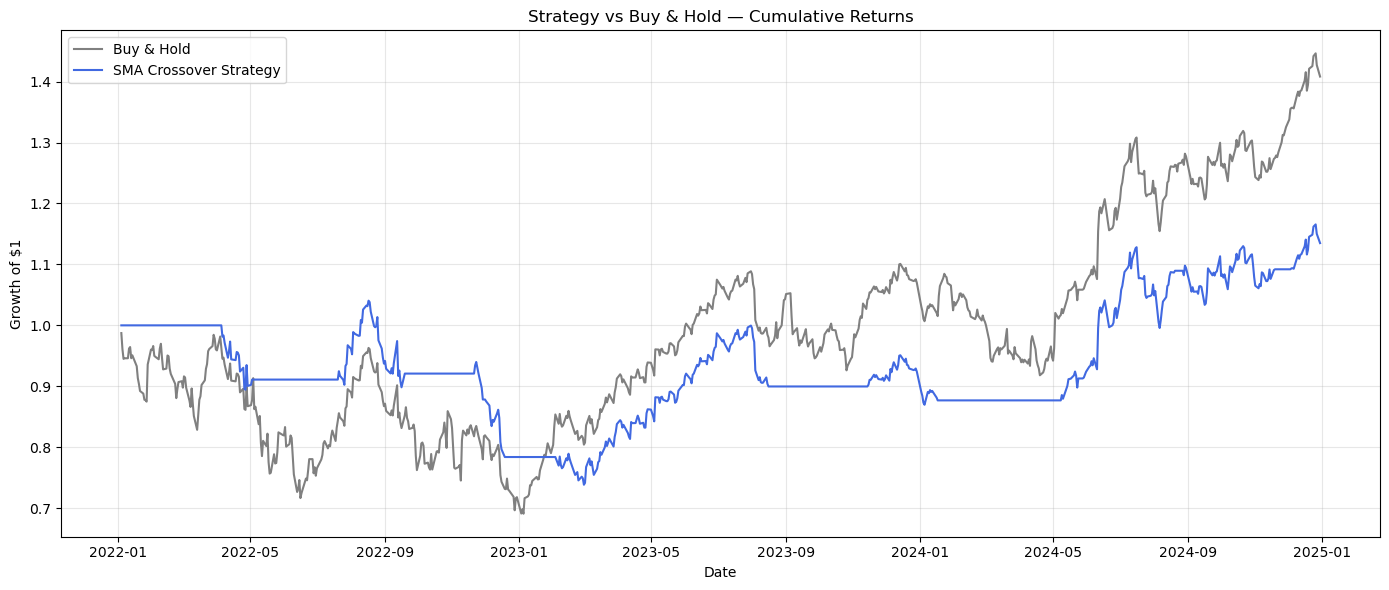

In [42]:
# Step 3: Visualise — did our strategy beat just holding AAPL?
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Cumulative_Market'], label='Buy & Hold', color='gray', linewidth=1.5)
plt.plot(df.index, df['Cumulative_Strategy'], label='SMA Crossover Strategy', color='royalblue', linewidth=1.5)
plt.title('Strategy vs Buy & Hold — Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Step 4: Compute the key performance metrics

# --- Total Return ---
# How much did we make overall, as a percentage?
total_return_strategy = df['Cumulative_Strategy'].iloc[-1] - 1
total_return_market   = df['Cumulative_Market'].iloc[-1] - 1

# --- Annualised Return ---
# Total return is hard to compare across different time periods.
# Annualising converts it to a "per year" number.
# n_years = how many years of data you have
n_days  = df['Strategy_Return'].dropna().count()
n_years = n_days / 252  # 252 = trading days in a year

annualised_strategy = (1 + total_return_strategy) ** (1 / n_years) - 1
annualised_market   = (1 + total_return_market)   ** (1 / n_years) - 1

# --- Sharpe Ratio ---
# Risk-adjusted return. Answers: "how much return did you get per unit of risk?"
# Formula: (average daily return / std of daily return) × sqrt(252)
# sqrt(252) scales it from daily to annual
# A Sharpe above 1.0 is generally considered good.
sharpe = (df['Strategy_Return'].mean() / df['Strategy_Return'].std()) * np.sqrt(252)

# --- Max Drawdown ---
# The worst peak-to-trough loss during the period.
# This is what tells you: "at its worst, how much would I have lost?"
cumulative = df['Cumulative_Strategy'].dropna()
rolling_max = cumulative.cummax()         # highest point reached so far at each date
drawdown    = (cumulative - rolling_max) / rolling_max  # how far below the peak we are
max_drawdown = drawdown.min()             # the worst drawdown (most negative value)

# --- Number of Trades ---
# Each time Signal changes from 0→1 or 1→0, that's a trade
trades = df['Signal'].diff().abs().sum()

In [44]:
# Step 5: Print a clean scorecard — same style as your existing one

print("=" * 52)
print(f"  AAPL — SMA Crossover Backtest Results")
print("=" * 52)
print(f"  {'Metric':<28} {'Strategy':>10} {'Buy&Hold':>10}")
print("-" * 52)
print(f"  {'Total Return':<28} {total_return_strategy:>9.1%} {total_return_market:>9.1%}")
print(f"  {'Annualised Return':<28} {annualised_strategy:>9.1%} {annualised_market:>9.1%}")
print(f"  {'Sharpe Ratio':<28} {sharpe:>10.2f} {'—':>10}")
print(f"  {'Max Drawdown':<28} {max_drawdown:>9.1%} {'—':>10}")
print(f"  {'Number of Trades':<28} {int(trades):>10} {'—':>10}")
print("=" * 52)

# Verdict
if annualised_strategy > annualised_market:
    verdict = "Strategy outperformed Buy & Hold"
else:
    verdict = "Buy & Hold outperformed the strategy"

print(f"\n  VERDICT: {verdict}")
print("=" * 52)

  AAPL — SMA Crossover Backtest Results
  Metric                         Strategy   Buy&Hold
----------------------------------------------------
  Total Return                     13.5%     40.8%
  Annualised Return                 4.3%     12.2%
  Sharpe Ratio                       0.34          —
  Max Drawdown                    -29.0%          —
  Number of Trades                     17          —

  VERDICT: Buy & Hold outperformed the strategy
